In [1]:
# Load and c;ean the data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("finaldataset.csv")

# Drop unnecessary column
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Convert date
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

# Drop missing dates
df = df.dropna(subset=["created_date"])

# Remove duplicates
df = df.drop_duplicates(subset="review_id")

# Sort by date
df = df.sort_values("created_date")

# Set index
df = df.set_index("created_date")

# Create Time series - Monthly

In [2]:
# Monthly Time Series

monthly_reviews = df.resample("M").size()
monthly_rating = df.resample("M")["rating"].mean()

# Plot review trend

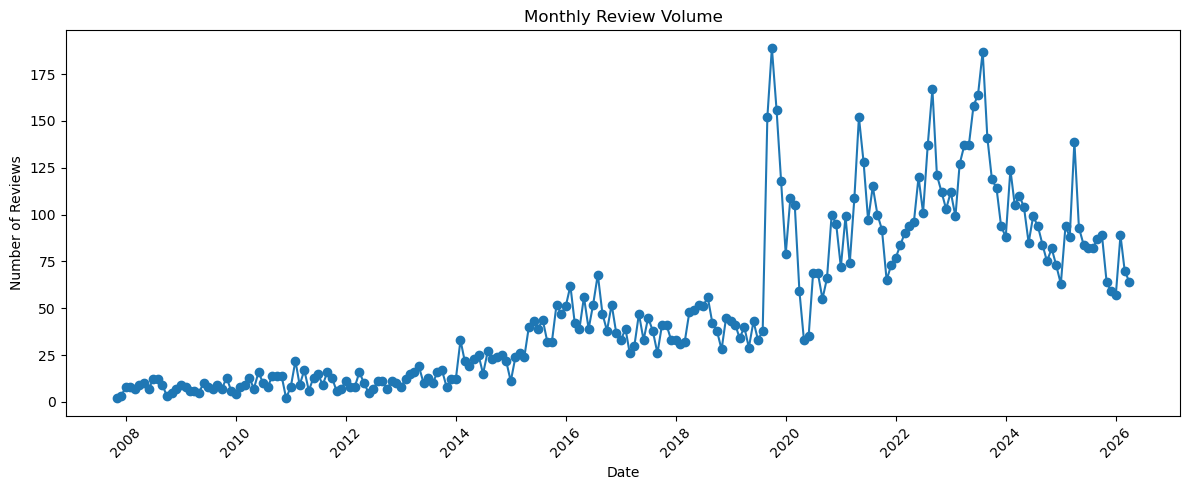

In [3]:
plt.figure(figsize=(12,5))
plt.plot(monthly_reviews, marker="o")
plt.title("Monthly Review Volume")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### The monthly review trend shows how customer engagement with restaurants has evolved over time. The data indicates a gradual increase in review activity, with a noticeable rise in recent years. This suggests that customer participation in online reviews has grown significantly, likely driven by increased digital engagement and platform usage. For The Roost, this indicates that customer feedback plays an important role in shaping restaurant visibility and reputation, making it essential to actively manage and encourage reviews.

# Plot rolling Average

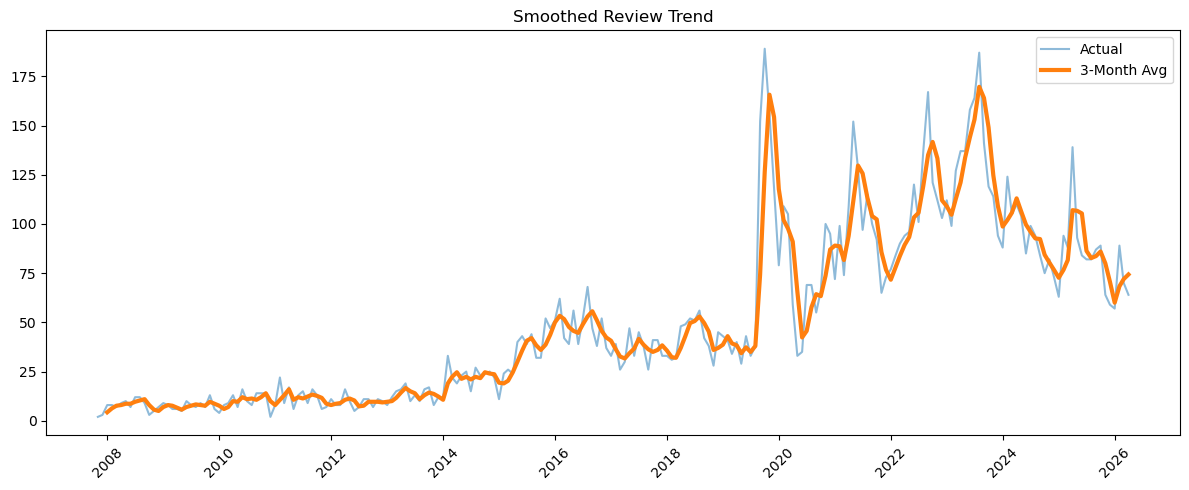

In [4]:
rolling_reviews = monthly_reviews.rolling(window=3).mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_reviews, label="Actual", alpha=0.5)
plt.plot(rolling_reviews, label="3-Month Avg", linewidth=3)

plt.title("Smoothed Review Trend")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### A rolling average was applied to smooth short-term fluctuations and better understand the underlying trend. The smoothed line clearly highlights sustained growth in review activity over time, reducing the impact of temporary spikes or drops. This confirms that the increase in customer engagement is consistent rather than random. For The Roost, this implies that entering the market now means operating in an environment where customer feedback is continuously growing and increasingly influential.

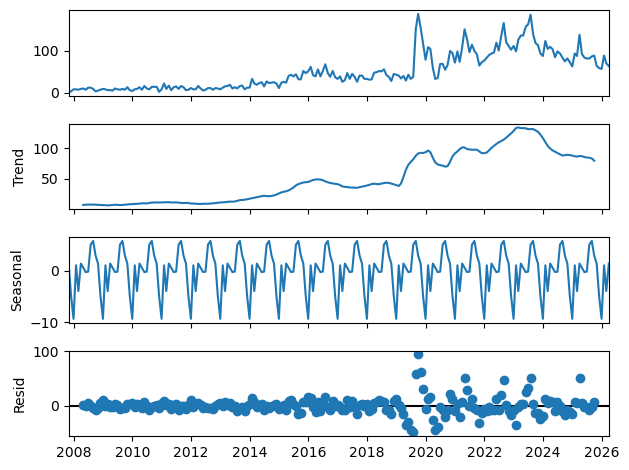

In [5]:
# Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_reviews, model="additive")

decomposition.plot()
plt.show()

#### The time series decomposition separates the data into trend, seasonal, and residual components to better understand underlying patterns. The trend component shows a clear upward movement, indicating long-term growth in customer engagement. The seasonal component suggests recurring patterns across time, which may be influenced by factors such as holidays or seasonal dining behavior. The residual component captures irregular fluctuations, which become more pronounced in recent years, indicating increased variability in customer activity. These findings suggest that the restaurant market is both growing and influenced by seasonal demand cycles.

In [6]:
# Stationarity Test

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_reviews.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.4198683717178515
p-value: 0.5727147822610891


#### We used the Augmented Dickey-Fuller (ADF) test to check whether the time series is stationary. We do this because many forecasting models assume that the statistical properties of the series, such as mean and variance, are stable over time. ADF statistic is about -1.42 and the p-value is about 0.573. Since the p-value is much greater than 0.05, the series is not stationary. This is expected because the data has a strong upward trend and changing variance over time. This means review activity has been evolving over time rather than fluctuating around a fixed average. That itself is an important business finding - customer attention in this market is dynamic, not stable.

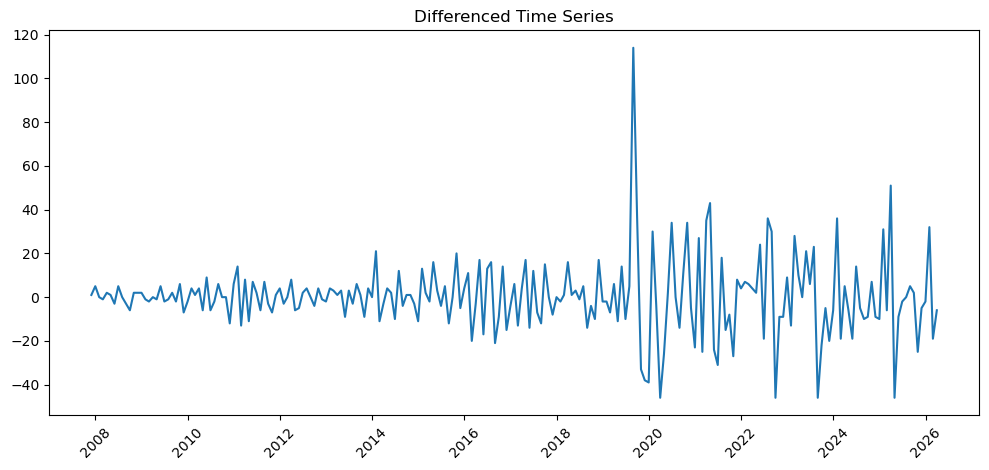

In [7]:
# Differencing

monthly_diff = monthly_reviews.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(monthly_diff)
plt.title("Differenced Time Series")
plt.xticks(rotation=45)
plt.show()

#### Differencing removes the trend and makes the series more stable for modeling, although volatility remains high in recent years.

In [24]:
# ARIMA Model

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_reviews, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  222
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -928.595
Date:                Mon, 13 Apr 2026   AIC                           1863.191
Time:                        15:23:43   BIC                           1873.385
Sample:                    10-31-2007   HQIC                          1867.307
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6874      0.053     12.921      0.000       0.583       0.792
ma.L1         -0.9126      0.036    -25.380      0.000      -0.983      -0.842
sigma2       260.7691      9.681     26.936      0.0

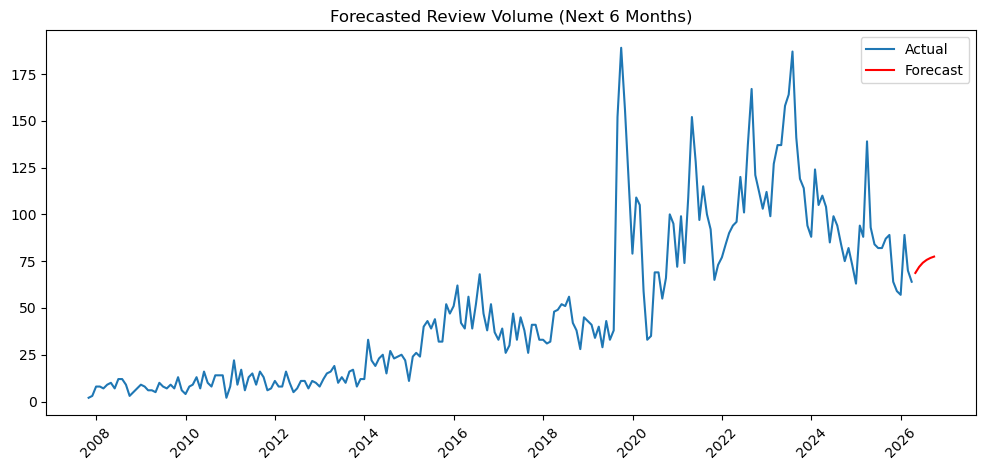

In [10]:
# Forecast future reviews

forecast = model_fit.forecast(steps=6)

plt.figure(figsize=(12,5))
plt.plot(monthly_reviews, label="Actual")
plt.plot(forecast, label="Forecast", color="red")

plt.title("Forecasted Review Volume (Next 6 Months)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### Forecasting analysis was performed using an ARIMA model to estimate future review trends based on historical data. The forecast suggests that review activity may stabilize in the near future rather than continuing at the same rate of growth. This indicates that while the market remains active, rapid increases in customer engagement may slow down. For The Roost, this means that success will depend more on capturing and maintaining customer satisfaction rather than relying solely on overall market growth.

<Figure size 1200x600 with 0 Axes>

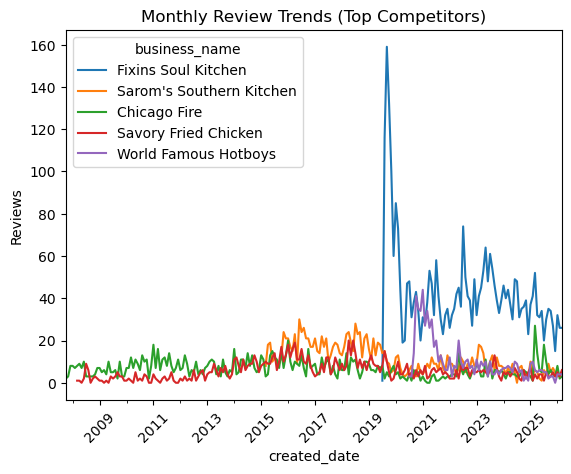

In [11]:
# Competitor time series

# Top 5 competitors
top_businesses = df["business_name"].value_counts().head(5).index

monthly_business = df.groupby("business_name").resample("M").size().unstack(0)

plt.figure(figsize=(12,6))
monthly_business[top_businesses].plot()

plt.title("Monthly Review Trends (Top Competitors)")
plt.ylabel("Reviews")
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

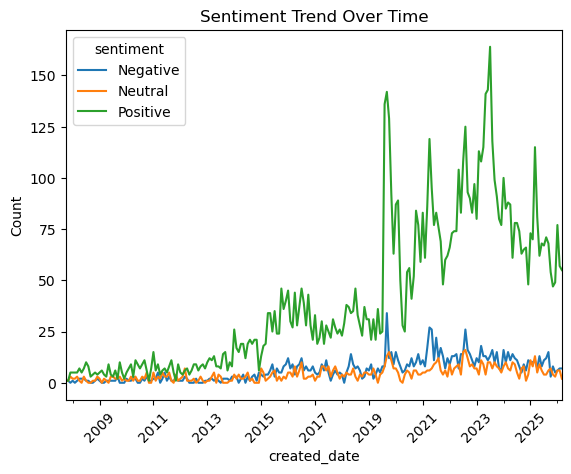

In [12]:
# Sentiment over time

# Create sentiment
def sentiment_label(r):
    if r >= 4:
        return "Positive"
    elif r == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(sentiment_label)

sentiment_trend = df.groupby("sentiment").resample("M").size().unstack(0)

plt.figure(figsize=(12,6))
sentiment_trend.plot()

plt.title("Sentiment Trend Over Time")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Sentiment analysis over time shows that positive reviews consistently dominate across the dataset, while negative reviews remain relatively low. This indicates that customers generally have favorable experiences with restaurants in the market. However, fluctuations in negative sentiment highlight areas where competitors may be underperforming. For The Roost, this suggests that maintaining high service quality and addressing common customer complaints can provide a competitive advantage.

# Insights

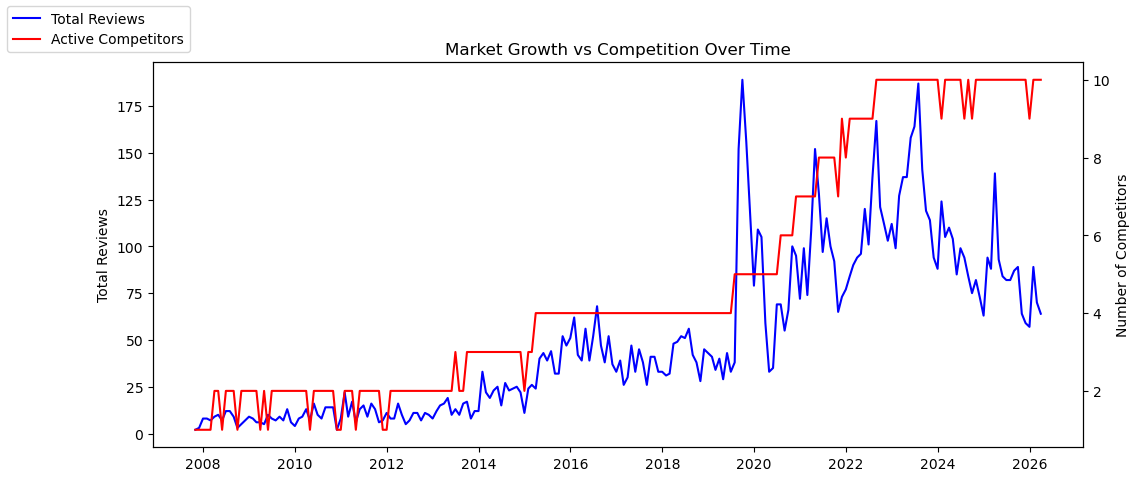

In [13]:
# Market growth Vs Competition

# Monthly total reviews (market size proxy)
monthly_reviews = df.resample("M").size()

# Number of active competitors per month
monthly_competitors = df.groupby(pd.Grouper(freq="M"))["business_name"].nunique()

# Plot
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(monthly_reviews, label="Total Reviews", color="blue")
ax1.set_ylabel("Total Reviews")

ax2 = ax1.twinx()
ax2.plot(monthly_competitors, label="Active Competitors", color="red")
ax2.set_ylabel("Number of Competitors")

plt.title("Market Growth vs Competition Over Time")
fig.legend(loc="upper left")
plt.show()

#### This graph compares total reviews with the number of active competitors over time. In the early years, both reviews and competitors are very low, which shows that the market was not very active. After around 2015, both start increasing steadily, and there is a sharp rise in review activity around 2020. At the same time, the number of competitors also increases, showing that more restaurants are entering the market. However, the increase in reviews is higher compared to the increase in competitors, which means customer demand is growing faster than competition. In recent years, the number of competitors becomes stable, while review activity remains high. This suggests that the market is competitive but still has strong customer engagement. For The Roost, this means there is good opportunity to enter the market, but it will need to differentiate itself to stand out among existing competitors.

# Quarterly trend Analysis

In [14]:
df["quarter"] = df.index.to_period("Q")

quarterly_reviews = df.groupby("quarter").size()
quarterly_rating = df.groupby("quarter")["rating"].mean()

C:\Users\varshinibalaganesh\AppData\Local\Temp\ipykernel_20272\4158759497.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["quarter"] = df.index.to_period("Q")


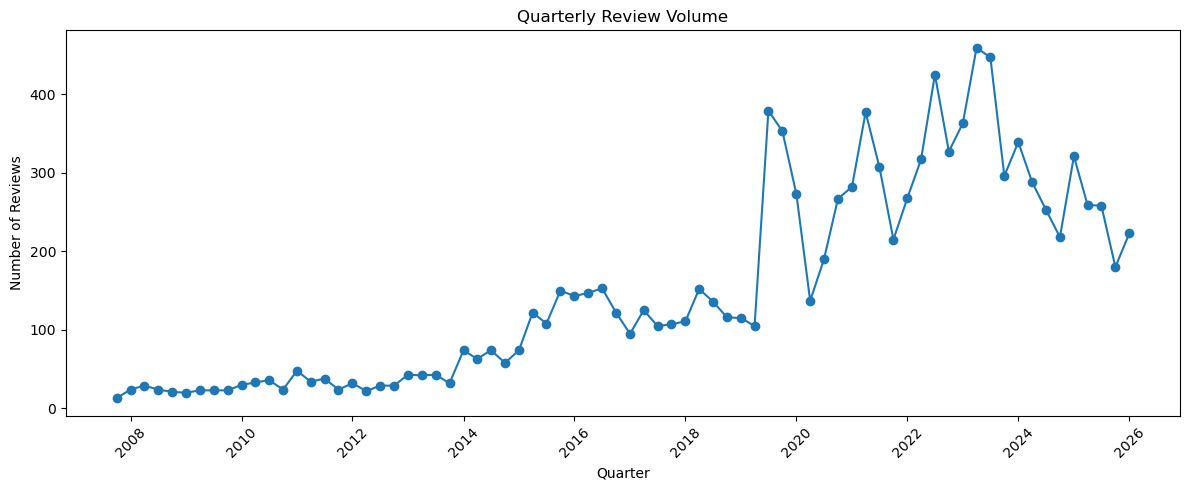

In [16]:
# Convert quarter to timestamp
quarterly_reviews.index = quarterly_reviews.index.to_timestamp()

# Plot
plt.figure(figsize=(12,5))
plt.plot(quarterly_reviews, marker="o")

plt.title("Quarterly Review Volume")
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Quarterly trend analysis was conducted to identify broader seasonal patterns in customer engagement. The results show that review activity varies across different quarters, indicating fluctuations in demand throughout the year. Certain quarters consistently experience higher review volumes, suggesting periods of increased dining activity. These seasonal patterns are useful for strategic planning, as The Roost can align its launch and promotional efforts with high-demand periods to maximize visibility and customer engagement.

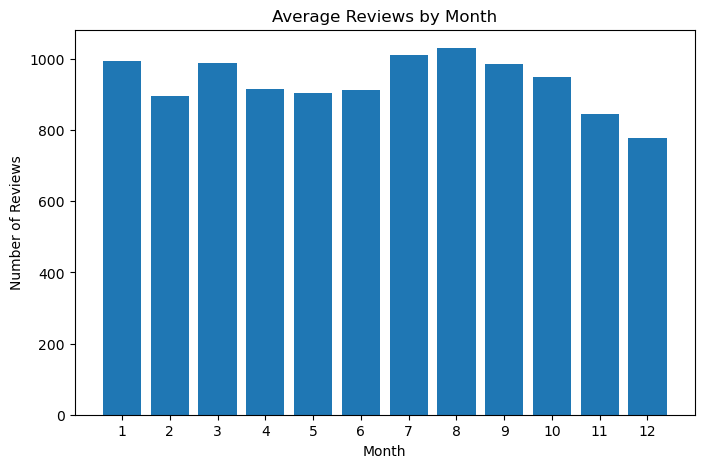

In [21]:
# Peak vs Off peak Months

# Extract month
df["month"] = df.index.month

# Average reviews per month
monthly_avg = df.groupby("month").size()

# Plot
plt.figure(figsize=(8,5))
plt.bar(monthly_avg.index, monthly_avg.values)

plt.title("Average Reviews by Month")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.xticks(range(1,13))
plt.show()

#### Monthly analysis highlights variations in customer activity across different months of the year. The results indicate that certain months like August and July consistently receive higher review volumes, reflecting peak demand periods, while others like December show lower activity levels. This pattern suggests the presence of seasonal dining behavior. For The Roost, these insights can be used to plan marketing campaigns, staffing, and promotions more effectively by targeting high-demand months and compensating for slower periods.

In [19]:
#Competitor entry timing

entry_time = df.groupby("business_name").apply(lambda x: x.index.min())

print(entry_time.sort_values())

business_name
Chicago Fire                2007-10-21 00:36:52+00:00
Savory Fried Chicken        2008-03-23 03:16:13+00:00
Tori's Place                2013-06-23 19:39:43+00:00
Sarom's Southern Kitchen    2015-03-13 19:12:48+00:00
Fixins Soul Kitchen         2019-07-31 19:13:23+00:00
World Famous Hotboys        2020-07-13 07:12:47+00:00
Bawk! by Urban Roots        2020-11-13 22:45:21+00:00
Angry Chickz                2021-03-26 17:30:20+00:00
Bear West BBQ & Soul Food   2021-11-13 03:04:08+00:00
Dave's Hot Chicken          2022-08-04 00:44:02+00:00
dtype: datetime64[ns, UTC]


#### Competitor entry analysis was performed by identifying the earliest review date for each restaurant, serving as a proxy for when each business entered the market. The results show a mix of long-established competitors and newer entrants. While established restaurants have maintained a strong presence over time, newer competitors have also been able to gain traction relatively quickly. This indicates that the market is competitive but not saturated, and new entrants like The Roost still have the opportunity to succeed with the right positioning and strategy.

<Figure size 1200x600 with 0 Axes>

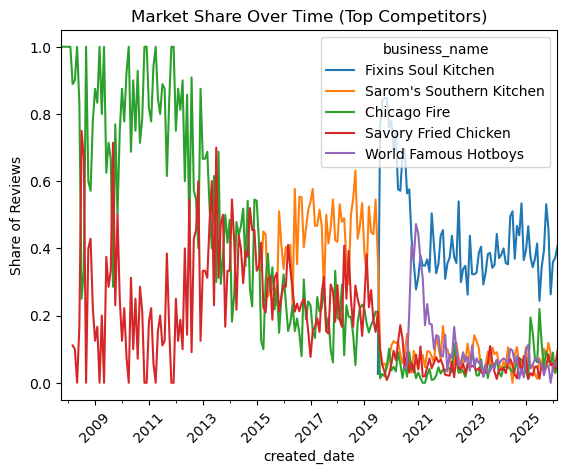

In [22]:
# Competitor dominance over time

monthly_business = df.groupby("business_name").resample("M").size().unstack(0)

# Convert to percentage (market share)
market_share = monthly_business.div(monthly_business.sum(axis=1), axis=0)

# Plot top competitors
top_businesses = df["business_name"].value_counts().head(5).index

plt.figure(figsize=(12,6))
market_share[top_businesses].plot()

plt.title("Market Share Over Time (Top Competitors)")
plt.ylabel("Share of Reviews")
plt.xticks(rotation=45)
plt.show()

#### The competitor time series analysis compares review activity across major restaurants over time. The results show that some competitors maintain consistently high visibility, indicating strong brand presence and customer engagement. At the same time, newer competitors demonstrate rapid growth, suggesting that the market is dynamic and allows for emerging brands to gain attention. This highlights the importance for The Roost to differentiate itself and build early momentum to compete effectively.